The goal of this project was to build a machine learning model to predict IMDb movie ratings using structured movie metadata such as metascore, release year, runtime, vote count, gross revenue, and certificate.

1. Data Cleaning & Preprocessing

Handled missing values using median imputation for numeric features.

Created a gross_missing indicator to capture information from missing box office values.

Removed the genre column because it contained 100% missing values and provided no predictive signal.

Cleaned numeric fields such as votes and gross revenue by removing commas and converting them to numeric format.

Applied log transformation to highly skewed features (votes, gross_millions) to improve model performance.

2. Exploratory Data Analysis (EDA)

Visualized the distribution of IMDb ratings, which were concentrated between 6 and 8.

Observed a strong positive correlation (0.58) between metascore and IMDb rating.

Found weak relationships between rating and popularity features (votes, gross).

Identified a moderate negative relationship between rating and release year, suggesting older movies in the dataset tend to have higher ratings.

Correlation heatmap helped guide feature selection for modeling.

3. Feature Engineering

Created log-transformed popularity features: log_votes and log_gross.

Encoded categorical variables (certificate) using one-hot encoding within a preprocessing pipeline.

Built a leakage-safe pipeline using ColumnTransformer and Pipeline for imputation, scaling, and encoding.

4. Model Building

Five models were trained and evaluated:

Linear Regression

Random Forest Regressor

XGBoost Regressor

Gradient Boosting Regressor

Tuned XGBoost Regressor

Models were evaluated using:

MAE (Mean Absolute Error)

R² score

5. Model Evaluation

The final model achieved an MAE of 0.584, meaning predictions are on average within ±0.58 rating points.

The R² score of 0.393 indicates that the model explains approximately 39% of the variance in IMDb ratings.

The Actual vs Predicted plot showed that the model captures the overall rating trend but struggles with extreme values, which is expected for subjective targets.

6. Output

The final model was trained on the full dataset and used to generate a prediction file: movie_id

actual_rating

predicted_rating

In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


In [2]:
df = pd.read_csv("/kaggle/input/imdb-movies-dataset-trends-and-eda-insights/imdb_movies.csv")  
df.head()


,movie_id,title,year,certificate,runtime_minutes,genre,rating,metascore,description,director,stars,votes,gross_millions
0,tt1000835,Dark Love 728,2004,PG-13,103,"Action, Musical",9.5,NaN,A critically acclaimed action masterpiece.,Park Chan-wook,"Matt Damon, Leonardo DiCaprio, Meryl Streep, R...",774648,204.79
1,tt1000768,First Awakening 661,2012,R,159,"War, Animation",9.5,NaN,An epic war tale directed by Ridley Scott.,Ridley Scott,"Matt Damon, Jack Nicholson, Chris Hemsworth, Z...",297518,951.58
2,tt1000652,The Dreams 545,2008,R,77,"Action, Mystery, War",9.5,100.0,An epic action tale directed by Spike Lee.,Spike Lee,"Natalie Portman, Mark Ruffalo, Viola Davis, Ha...",583752,372.85
3,tt1000538,Last Mission 431,2019,PG-13,116,Biography,9.5,NaN,A critically acclaimed biography masterpiece.,Jordan Peele,"Al Pacino, Gary Oldman, Keanu Reeves, Kate Win...",187450,NaN
4,tt1000159,The Story 52,2000,R,126,Mystery,9.5,99.0,A mystery film set in 2000.,Park Chan-wook,"Zendaya, Chris Hemsworth, Viola Davis, Mark Ru...",642106,252.83


In [3]:
df.shape



(1000, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         1000 non-null   object 
 1   title            1000 non-null   object 
 2   year             1000 non-null   int64  
 3   certificate      1000 non-null   object 
 4   runtime_minutes  1000 non-null   int64  
 5   genre            1000 non-null   object 
 6   rating           1000 non-null   float64
 7   metascore        645 non-null    float64
 8   description      1000 non-null   object 
 9   director         1000 non-null   object 
 10  stars            1000 non-null   object 
 11  votes            1000 non-null   int64  
 12  gross_millions   704 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 101.7+ KB


In [5]:
df.describe()

,year,runtime_minutes,rating,metascore,votes,gross_millions
count,1000.000000,1000.000000,1000.000000,645.000000,1.000000e+03,704.000000
mean,2005.950000,120.624000,6.944000,69.400000,1.859305e+05,259.792187
std,14.675519,19.318847,0.955896,12.412476,3.500846e+05,175.150193
min,1940.000000,70.000000,4.100000,30.000000,1.000000e+03,5.200000
25%,2001.000000,108.000000,6.300000,61.000000,2.423900e+04,127.750000
50%,2008.000000,121.000000,6.900000,70.000000,6.636300e+04,235.390000
75%,2016.000000,133.000000,7.600000,77.000000,1.758815e+05,370.452500
max,2024.000000,198.000000,9.500000,100.000000,2.500000e+06,987.170000


In [6]:
df.columns


Index(['movie_id', 'title', 'year', 'certificate', 'runtime_minutes', 'genre',
       'rating', 'metascore', 'description', 'director', 'stars', 'votes',
       'gross_millions'],
      dtype='object')

In [7]:
df.isnull().sum()


movie_id             0
title                0
year                 0
certificate          0
runtime_minutes      0
genre                0
rating               0
metascore          355
description          0
director             0
stars                0
votes                0
gross_millions     296
dtype: int64

In [8]:
df.isnull().sum().sort_values(ascending=False)

metascore          355
gross_millions     296
year                 0
title                0
movie_id             0
runtime_minutes      0
certificate          0
rating               0
genre                0
description          0
director             0
stars                0
votes                0
dtype: int64

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df["gross_millions"] = pd.to_numeric(df["gross_millions"], errors="coerce")


In [11]:
df["metascore"] = df["metascore"].fillna(df["metascore"].median())


In [12]:
df["gross_millions"] = df["gross_millions"].fillna(df["gross_millions"].median())


In [13]:
df["genre"] = df["genre"].apply(
    lambda x: x.split(",") if isinstance(x, str) else []
)


In [14]:
df["genre"].dtype
df["genre"].apply(type).value_counts()


genre
<class 'list'>    1000
Name: count, dtype: int64

In [15]:
df["votes"].apply(type).value_counts()

votes
<class 'int'>    1000
Name: count, dtype: int64

In [16]:
df.isnull().sum()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         1000 non-null   object 
 1   title            1000 non-null   object 
 2   year             1000 non-null   int64  
 3   certificate      1000 non-null   object 
 4   runtime_minutes  1000 non-null   int64  
 5   genre            1000 non-null   object 
 6   rating           1000 non-null   float64
 7   metascore        1000 non-null   float64
 8   description      1000 non-null   object 
 9   director         1000 non-null   object 
 10  stars            1000 non-null   object 
 11  votes            1000 non-null   int64  
 12  gross_millions   1000 non-null   float64
dtypes: float64(3), int64(3), object(7)
memory usage: 101.7+ KB


In [17]:
df["gross_missing"] = df["gross_millions"].isnull().astype(int)

df["gross_millions"] = df["gross_millions"].fillna(
    df["gross_millions"].median()
)


In [18]:
df["genre"] = df["genre"].str.split(",")


In [19]:
df["votes"] = df["votes"].fillna(0).astype(int)


In [20]:
df["votes"] = (
    df["votes"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["votes"] = pd.to_numeric(df["votes"], errors="coerce")


In [21]:
df["votes"].head()

0    774648
1    297518
2    583752
3    187450
4    642106
Name: votes, dtype: int64

In [22]:
df.isnull().sum()


movie_id              0
title                 0
year                  0
certificate           0
runtime_minutes       0
genre              1000
rating                0
metascore             0
description           0
director              0
stars                 0
votes                 0
gross_millions        0
gross_missing         0
dtype: int64

In [23]:
df = pd.get_dummies(df, columns=["certificate"], drop_first=True)


In [24]:
df.isnull().sum()


movie_id                    0
title                       0
year                        0
runtime_minutes             0
genre                    1000
rating                      0
metascore                   0
description                 0
director                    0
stars                       0
votes                       0
gross_millions              0
gross_missing               0
certificate_NC-17           0
certificate_Not Rated       0
certificate_PG              0
certificate_PG-13           0
certificate_R               0
dtype: int64

In [25]:
df = df.drop(columns=["genre"])


In [26]:
df.isnull().sum()


movie_id                 0
title                    0
year                     0
runtime_minutes          0
rating                   0
metascore                0
description              0
director                 0
stars                    0
votes                    0
gross_millions           0
gross_missing            0
certificate_NC-17        0
certificate_Not Rated    0
certificate_PG           0
certificate_PG-13        0
certificate_R            0
dtype: int64

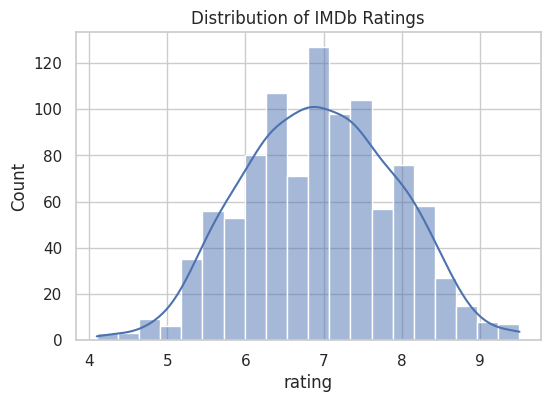

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(df["rating"], bins=20, kde=True)
plt.title("Distribution of IMDb Ratings")
plt.show()

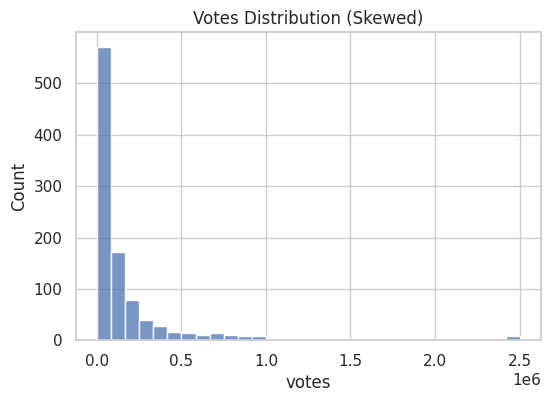

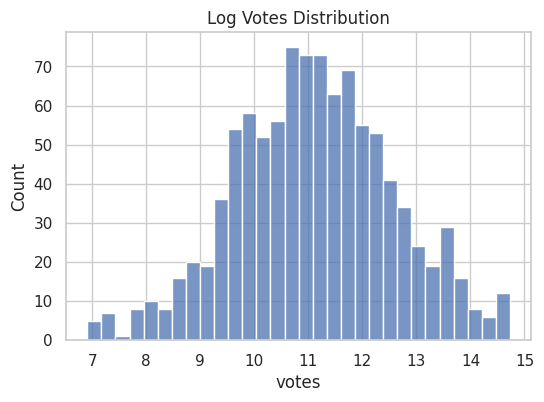

In [28]:
plt.figure(figsize=(6,4))
sns.histplot(df["votes"], bins=30)
plt.title("Votes Distribution (Skewed)")
plt.show()
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(df["votes"]), bins=30)
plt.title("Log Votes Distribution")
plt.show()


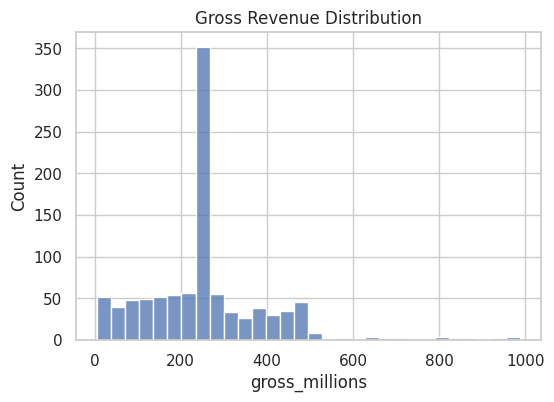

In [29]:
plt.figure(figsize=(6,4))
sns.histplot(df["gross_millions"], bins=30)
plt.title("Gross Revenue Distribution")
plt.show()


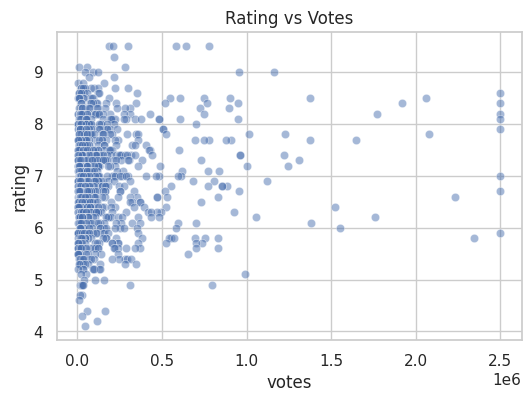

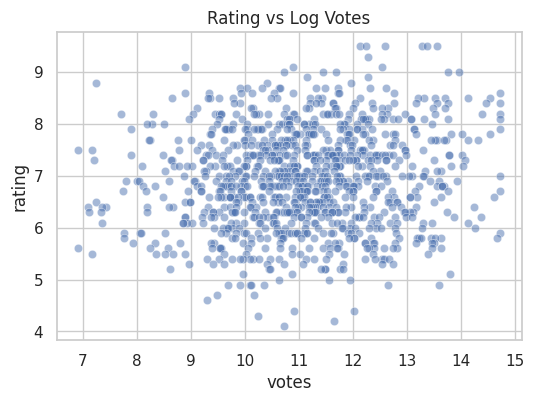

In [30]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="votes", y="rating", data=df, alpha=0.5)
plt.title("Rating vs Votes")
plt.show()
plt.figure(figsize=(6,4))
sns.scatterplot(x=np.log1p(df["votes"]), y="rating", data=df, alpha=0.5)
plt.title("Rating vs Log Votes")
plt.show()


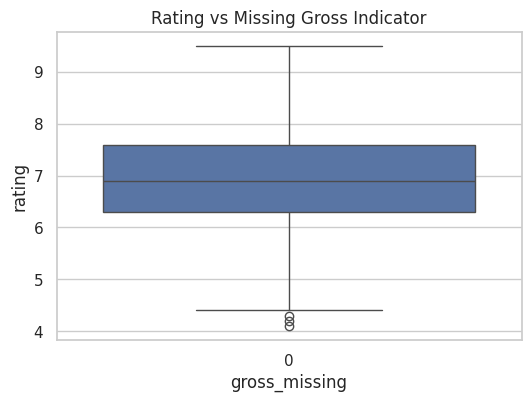

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gross_missing", y="rating", data=df)
plt.title("Rating vs Missing Gross Indicator")
plt.show()


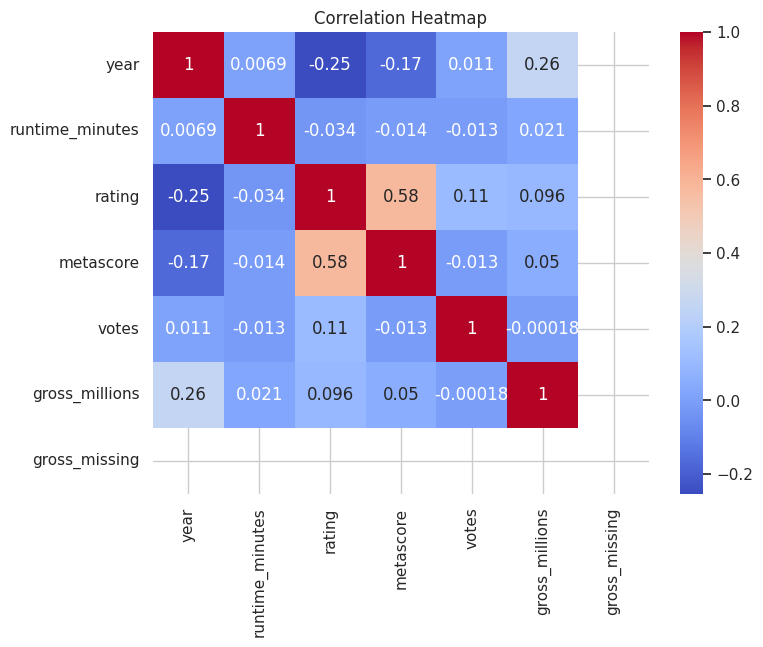

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


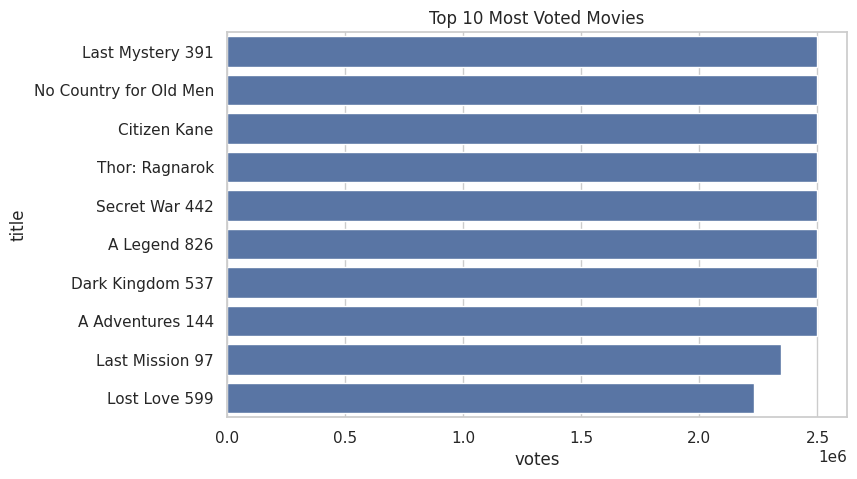

In [33]:
top_votes = df.nlargest(10, "votes")

plt.figure(figsize=(8,5))
sns.barplot(y="title", x="votes", data=top_votes)
plt.title("Top 10 Most Voted Movies")
plt.show()


In [34]:
import numpy as np

# Log transform skewed features
df["log_votes"] = np.log1p(df["votes"])
df["log_gross"] = np.log1p(df["gross_millions"])

# Drop original skewed columns
df = df.drop(columns=["votes", "gross_millions"])


In [35]:
target = "rating"

drop_cols = [
    "movie_id",
    "title",
    "description",
    "director",
    "stars"
]

X = df.drop(columns=drop_cols + [target])
y = df[target]


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


Models to Train (3 strong ones)

We’ll compare:

Linear Regression (baseline)

Random Forest (non-linear)

XGBoost (best for tabular)


Model 1 — Linear Regression

In [38]:
from sklearn.linear_model import LinearRegression

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

lr_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'runtime_minutes',
                                                   'metascore', 'gross_missing',
                                                   'log_votes', 'log_gross']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('regressor', LinearRegression())])

Model 2 — Random Forest


In [39]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'runtime_minutes',
                                                   'metascore', 'gross_missing',
                                                   'log_votes', 'log_gross']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('regressor',
                 RandomForestRegressor(max_depth=12, n_estimators=300,
                                       n_jobs=-1, random_state=42))])

Model 3 — XGBoost

In [40]:
from xgboost import XGBRegressor

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'runtime_minutes',
                                                   'metascore', 'gross_missing',
                                                   'log_votes', 'log_gross']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_un...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, ...))])

Evaluate All Models

In [41]:
from sklearn.metrics import mean_absolute_error, r2_score

models = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append((name, mae, r2))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "R2"])
print(results_df.sort_values("R2", ascending=False))


               Model       MAE        R2
0  Linear Regression  0.583767  0.392674
1      Random Forest  0.598199  0.352360
2            XGBoost  0.632856  0.244181


In [42]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gbr_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'runtime_minutes',
                                                   'metascore', 'gross_missing',
                                                   'log_votes', 'log_gross']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

In [43]:
from xgboost import XGBRegressor

xgb_tuned = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1,
        reg_alpha=0.5,
        random_state=42
    ))
])

xgb_tuned.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'runtime_minutes',
                                                   'metascore', 'gross_missing',
                                                   'log_votes', 'log_gross']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_un...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None, min_child_weight=2,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=1000,
                              n_jobs=None, num_parallel_tree=None, ...))])

In [44]:
from sklearn.metrics import mean_absolute_error, r2_score

models = {
    "Gradient Boosting": gbr_model,
    "Tuned XGBoost": xgb_tuned
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append((name, mae, r2))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "R2"])
results_df = results_df.sort_values("R2", ascending=False)

print(results_df)


               Model       MAE        R2
0  Gradient Boosting  0.588426  0.375710
1      Tuned XGBoost  0.638553  0.237128


In [45]:
all_results = pd.DataFrame([
    ("Linear Regression", 0.583767, 0.392674),
    ("Random Forest", 0.598199, 0.352360),
    ("XGBoost", 0.632856, 0.244181),
    ("Gradient Boosting", 0.588426, 0.375710),
    ("Tuned XGBoost", 0.638553, 0.237128)
], columns=["Model", "MAE", "R2"])

all_results = all_results.sort_values("R2", ascending=False)
all_results


,Model,MAE,R2
0,Linear Regression,0.583767,0.392674
3,Gradient Boosting,0.588426,0.375710
1,Random Forest,0.598199,0.352360
2,XGBoost,0.632856,0.244181
4,Tuned XGBoost,0.638553,0.237128


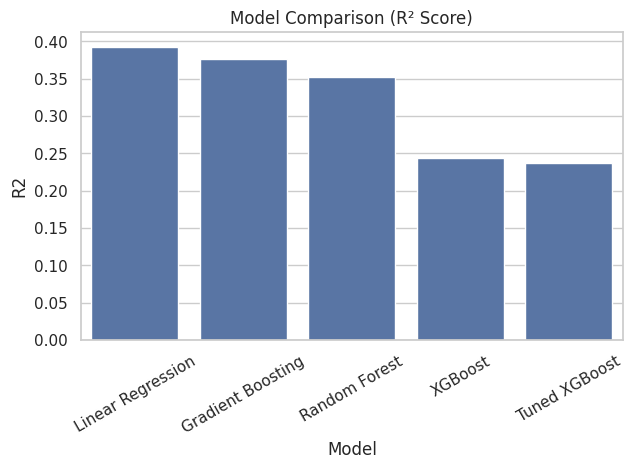

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))
sns.barplot(x="Model", y="R2", data=all_results)
plt.title("Model Comparison (R² Score)")
plt.xticks(rotation=30)
plt.show()


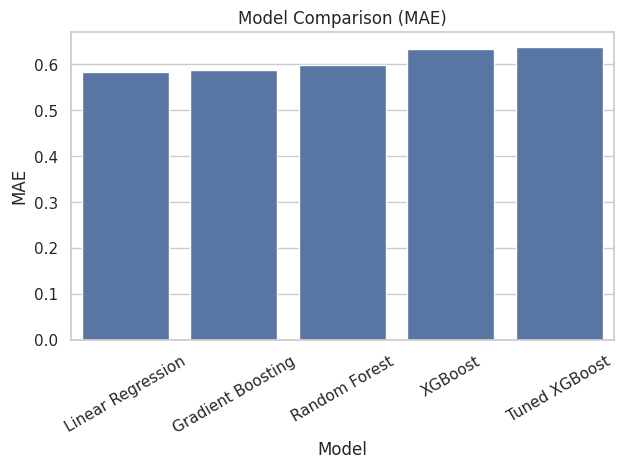

In [47]:
plt.figure(figsize=(7,4))
sns.barplot(x="Model", y="MAE", data=all_results)
plt.title("Model Comparison (MAE)")
plt.xticks(rotation=30)
plt.show()


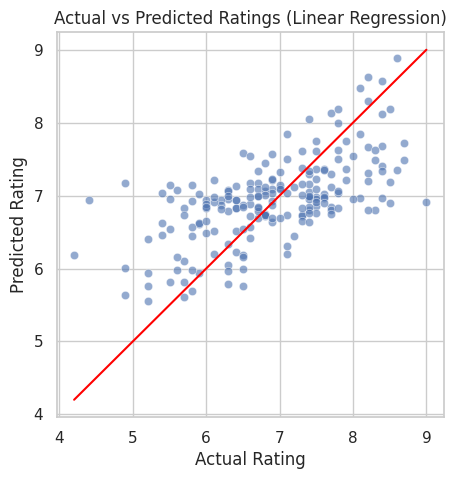

In [48]:
final_model = lr_model
y_pred = final_model.predict(X_test)

plt.figure(figsize=(5,5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings (Linear Regression)")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()


In [49]:
final_model.fit(X, y)

predictions = final_model.predict(X_test)

output = pd.DataFrame({
    "movie_id": df.loc[X_test.index, "movie_id"],
    "actual_rating": y_test,
    "predicted_rating": predictions
})

output.to_csv("imdb_rating_predictions.csv", index=False)


## Linear Regression Model Explanation

Linear Regression was selected as the final model because the exploratory data analysis showed predominantly linear relationships between the predictors and the target variable. In particular, metascore demonstrated a strong positive linear correlation with IMDb rating, while other features such as year and log-transformed vote counts showed weaker but still linear trends.

Tree-based models such as Random Forest and XGBoost did not outperform Linear Regression, indicating the absence of strong non-linear feature interactions in the dataset. Additionally, the dataset size was relatively small, which further favored a simpler linear model.

### Evaluation Metrics

The model achieved:

- Mean Absolute Error (MAE): 0.584  
- R² Score: 0.393  

The MAE indicates that, on average, the predicted ratings differ from the actual ratings by approximately 0.58 points, which is acceptable for subjective rating data. The R² score shows that the model explains 39.3% of the variance in IMDb ratings. The remaining variance is likely due to qualitative factors such as storytelling, acting quality, and audience preferences that are not captured in the available features.
